<a href="https://colab.research.google.com/github/dongukl/dongukl-robot_danger_detection/blob/main/notebooks/01_data_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q

In [2]:
from google.colab import files
files.upload()

# 3. 인증 파일 위치 설정
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle 연결 완료!")

Saving kaggle.json to kaggle.json
Kaggle 연결 완료!


In [15]:
# 1. 다운로드
!wget "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz" \
     -O /content/UCSD.tar.gz \
     --progress=bar:force 2>&1

--2026-05-02 11:16:32--  http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz
Resolving www.svcl.ucsd.edu (www.svcl.ucsd.edu)... 169.228.63.130
Connecting to www.svcl.ucsd.edu (www.svcl.ucsd.edu)|169.228.63.130|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 740306953 (706M) [application/x-gzip]
Saving to: ‘/content/UCSD.tar.gz’

/content/UCSD.tar.g 100%[===================>] 706.01M  43.3MB/s    in 17s     

2026-05-02 11:16:49 (41.7 MB/s) - ‘/content/UCSD.tar.gz’ saved [740306953/740306953]



In [16]:
# 1. 다운로드
!wget "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz" \
     -O /content/UCSD.tar.gz \
     --progress=bar:force 2>&1

압축 해제 완료!


In [17]:
# 3. 폴더 구조 확인
import os

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 3:
        # 파일 3개만 미리보기
        for f in sorted(files)[:3]:
            print(f'{indent}  {f}')

data/
  UCSD_Anomaly_Dataset.v1p2/
    UCSDped2/
      Train/
        .DS_Store
        ._.DS_Store
      Test/
        .DS_Store
        ._.DS_Store
        ._UCSDped2.m
    UCSDped1/
      Train/
        .DS_Store
        ._.DS_Store
      Test/
        .DS_Store
        ._UCSDped1.m
        UCSDped1.m


총 훈련 프레임 수: 2550


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

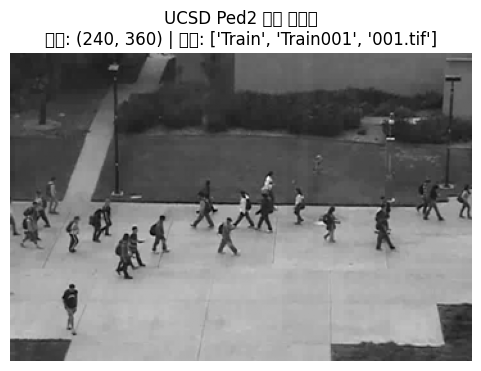

In [18]:
# 4. 샘플 이미지 1장 확인
import cv2
import matplotlib.pyplot as plt
import glob

# Ped2 훈련 프레임 찾기
frames = sorted(glob.glob('/content/data/**/UCSDped2/Train/**/*.tif', recursive=True))
print(f"총 훈련 프레임 수: {len(frames)}")

# 첫 번째 프레임 시각화
img = cv2.imread(frames[0], cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(6, 4))
plt.imshow(img, cmap='gray')
plt.title(f'UCSD Ped2 샘플 프레임\n크기: {img.shape} | 경로: {frames[0].split("/")[-3:]}')
plt.axis('off')
plt.show()